In [1]:
import pandas as pd
import pandas


In [2]:
%matplotlib inline
from numpy import array, linspace ; from numpy.random import randint
from matplotlib.pyplot import hist, xticks, show
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
# synthesize some data 
font_size = 30
font = {
    'family' : 'serif',
    'weight':'normal',
        'size'   : font_size}


matplotlib.rc('font', **font)
plt.rcParams.update({
    "text.usetex": True,
})

# plt.rc('text', usetex=True)
import seaborn as sns
pallete = sns.color_palette("Set1", 4)
dgl_color = pallete[0]
quiver_color = pallete[1]
groot_color = pallete[2]
edge2color = {"GSplit": "tab:blue",
         "DistCache": "tab:purple"}
quiver_color = edge2color['DistCache']
groot_color = edge2color['GSplit']

hatches = list('-*/o')

pallete = sns.color_palette("Set1", 4)
pallete

[(0.8941176470588236, 0.10196078431372549, 0.10980392156862745),
 (0.21568627450980393, 0.49411764705882355, 0.7215686274509804),
 (0.30196078431372547, 0.6862745098039216, 0.2901960784313726),
 (0.596078431372549, 0.3058823529411765, 0.6392156862745098)]

In [6]:


def plot_bar(ax,position, df, color, width):
    if len(df) != 1:
#         print(df, df['hid_size'])
        row = df
        row = row[row['duration (s)']!= -1]
        row = row[row['duration (s)']==row['duration (s)'].min()]
    sampling_time = df['sampling (s)'].item()
    if sampling_time != "oom":
        n_epochs = float(df['num_epoch'].item())
        sampling_time = float(sampling_time)
        data_loading = float(df['feature (s)'].item())
        training_time = (float(df['forward (s)'].item()) + float(df['backward (s)'].item()))
        
        ax.bar([position], [sampling_time + data_loading + training_time], width, color = color, edgecolor = 'black', alpha = 0.7 )
        return sampling_time + data_loading + training_time
    else:
        ax.bar([position], [0], width, color = color, edgecolor = 'black' )
        ax.text(count + .3 * width, 4,'OOM', ha = 'center', \
                 rotation = 90,fontsize=fontsize, weight = "bold",color = color)  
        return None
print(1)

1


/tmp/ipykernel_362239/3966403292.py:153: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


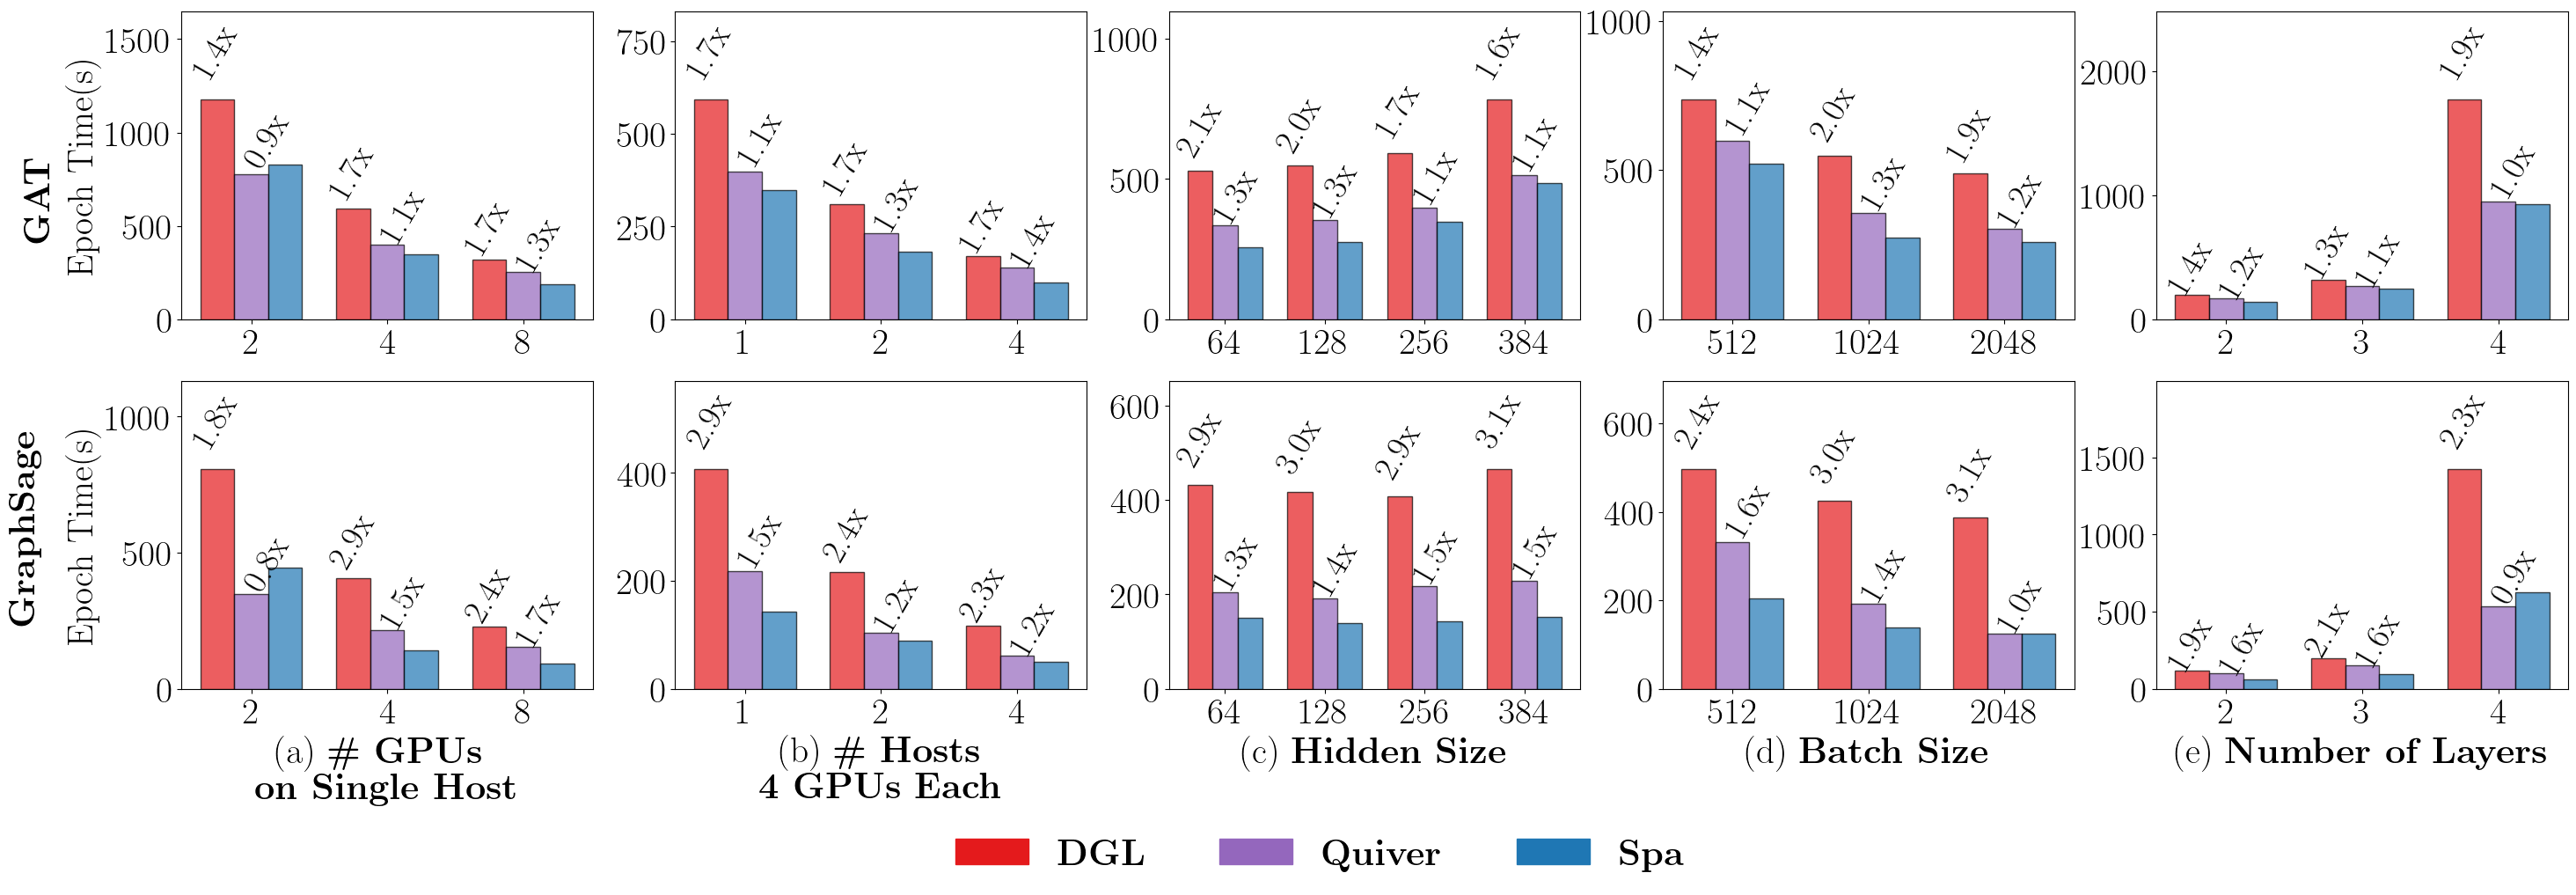

In [10]:
N = 2
import numpy as np
ind = np.arange(N) 
width = .2


datasets = {'friendster':'FR'}
datasets = {'papers100M':'PR'}
models = ['gat', 'sage']
model_label = {'gat':'GAT','sage':'GraphSage'}
model_cap = {'gat':'GAT','sage':'SAGE'}

fig, ax  = plt.subplots(2, 5, figsize=(35, 10))

dataset_id = 0
dataset = 'friendster'


for y_id in [0,1,2,3,4]:
# for y_id in [2]:
    if y_id == 0:
        save_file = "scalability"
        abalation_h = 'world_size'
        x_label = r'(a) \textbf{\# GPUs\\on Single Host}'
    if y_id == 1:
        save_file = "distributed"
        abalation_h = 'world_size'
        x_label = r'(b) \textbf{\# Hosts\\  4 GPUs Each}'
    if y_id == 2:
        save_file = "hidden"
        abalation_h = 'hid_size'
        x_label = r'(c) \textbf{Hidden Size}'
    if y_id == 4:
        save_file = "depth"
        abalation_h = 'fanouts'
        x_label = r'(e) \textbf{Number of Layers}'
    if y_id == 3:
        save_file = "batch_size"
        abalation_h = 'batch_size'
        x_label = r'(d) \textbf{Batch Size}'
    
    df1 = pandas.read_csv(f'arxiv_logs/nvlink_{save_file}.csv')
    df2 = pandas.read_csv(f'arxiv_logs/nvlink_main.csv')
    if save_file != 'depth':
        df = pd.concat([df1,df2], axis = 0)
    else:
        df = df1
    df1 = pandas.read_csv(f'arxiv_logs/nvlink_{save_file}.csv')
    df2 = pandas.read_csv(f'arxiv_logs/nvlink_main.csv')
    if save_file != 'depth':
        df = pd.concat([df1,df2], axis = 0)
    else:
        df = df1
    abalation_v = list(df[abalation_h].unique())
#     abalation_v.sort()
    if save_file == "scalability":
        abalation_v.sort()
        abalation_v = ["2 * 1","4 * 1", "8 * 1"]
    if save_file == "distributed":
        abalation_v = ["4 * 1","4 * 2", "4 * 4"]

    df = df[df['graph_name'] == dataset]
    if save_file == "hidden":
        if dataset == 'friendster':
            abalation_v = [64,128,256,384]
        else:
            abalation_v = [64,128,256,512]
    if save_file == "depth":
        abalation_v = ["[30, 30]" ,"[10, 10, 10]","[10, 10, 10, 10]"]
#         abalation_v = ["[30, 30]","[15, 15, 15]","[10, 10, 10, 10]"]
    for x_id,model in enumerate(models):
        x_tick = []
        x_tick_val = []
        count = 0
        y_lim = 0
        for ab_id, abalation_val in enumerate(abalation_v):
            if save_file == "batch_size" or save_file =="depth":
                dataset_df = df[(df['graph_name'] == dataset) & (df['model'] == model) \
                                & (df[abalation_h] == abalation_val) & (df["hid_size"]==128)]
            else:
                dataset_df = df[(df['graph_name'] == dataset) & (df['model'] == model) \
                                & (df[abalation_h] == abalation_val)]   
            dgl_row = dataset_df[dataset_df['system'].str.contains('dgl')]
            quiver_row = dataset_df[dataset_df['system'].str.contains('dist_cache')]
#             print(dataset_df['timestamp'])    
            if len(quiver_row) == 0:
                quiver_row = dataset_df[dataset_df['system'].str.contains('quiver')]
            groot_row = dataset_df[dataset_df['system'].str.contains('split')]
            if len(groot_row) == 2:
                groot_row =groot_row[groot_row['sample_mode'] == 'gpu']
            dgl_time = plot_bar(ax[x_id][dataset_id * 2 + y_id], count, dgl_row, dgl_color, width)
            dgl_position = count
            if(dgl_time != None):
                y_lim = max(dgl_time, y_lim)
            count = count + width 
            quiver_time =plot_bar(ax[x_id][dataset_id * 2 + y_id], count, quiver_row, quiver_color, width)
            y_lim = max(quiver_time, y_lim)
            quiver_position = count 
            count = count + width
            groot_time = plot_bar(ax[x_id][dataset_id * 2 + y_id], count, groot_row, groot_color, width)
            if(quiver_time != None):
                y_lim = max(quiver_time, y_lim)
            if(quiver_time != None) and (dgl_time != None):
#                     print(groot_time, quiver_time, quiver_time/groot_time, abalation_val, model, abalation_val)
                ax[x_id][dataset_id * 2 + y_id].text(quiver_position +.1,   quiver_time * 1.05 ,
                                                     '{:.1f}x'.format(quiver_time/groot_time), ha = 'center', \
                         rotation = 60,fontsize=font_size - 2)  

            x_tick.append(count - width)
            if abalation_h == "fanouts":
                dic = {"[30, 30]":2,"[10, 10, 10]":3,"[10, 10, 10, 10]":4}
                x_tick_val.append(f"{dic[abalation_val]}")
            else:
                if abalation_h == 'batch_size':
                    x_tick_val.append(abalation_val)
                else:
                    if save_file == "distributed":
                        dic = {"4 * 1":1,"4 * 2":2,"4 * 3":3,"4 * 4":4}
                        x_tick_val.append(f"{dic[abalation_val]}")
                    else:
                        if save_file=="scalability":
                            dic = {"2 * 1":2,"4 * 1":4,"8 * 1":8}
                            x_tick_val.append(f"{dic[abalation_val]}")
                        else:
                            x_tick_val.append(f"{abalation_val}")

            if(groot_time != None) and (dgl_time != None):
                ax[x_id][dataset_id * 2 + y_id].text(dgl_position ,   dgl_time * 1.1 ,'{:.1f}x'.\
                         format(dgl_time/groot_time), ha = 'center', \
                     rotation = 60,fontsize=font_size - 2)
#                 print(dgl_time, groot_time, dgl_time/groot_time, abalation_val, model, abalation_val)
            count = count + width * 2
        if x_id == 1:    
            ax[x_id][dataset_id * 2 +  y_id].set_xlabel(f"{x_label}")
        ax[x_id][dataset_id * 2 +  y_id].set_xticks(x_tick, x_tick_val)
        ax[x_id][dataset_id * 2 +  y_id].set_ylim([0,y_lim * 1.4])

        if model== "sage":
            ax[x_id][0].set_ylabel(r'\textbf{GraphSage} \\ \\ \\ Epoch Time(s)')
        else:
            ax[x_id][0].set_ylabel(r'\textbf{   GAT   } \\ \\ Epoch Time(s)')
            
patches = []
patches.append(mpatches.Patch(color=dgl_color, label=r'\textbf{DGL}'))
patches.append(mpatches.Patch(color=quiver_color, label=r'\textbf{Quiver}'))
patches.append(mpatches.Patch(color=groot_color, label=r'\textbf{Spa}'))
# patches.append(mpatches.Patch( lw=1., edgecolor='black', fill=False,  label='Sampling (S)',color = None))
# patches.append(mpatches.Patch(hatch = '//', lw=1., edgecolor='black', fill=False,  label='Loading (L)',color = None))               
# patches.append( mpatches.Patch(hatch = '..', lw=1., edgecolor='black', fill=False,  label='Forward and Backward (FB)',color = None))          
plt.legend(handles=patches, ncol=len(patches), loc="lower left", frameon=False, bbox_to_anchor=  (-3, -0.7))


plt.tight_layout()

plt.savefig(f'pdfs_arxiv/abalations_spa_{dataset}_combined.pdf',bbox_inches="tight")

In [ ]:
a = [1,2,3]
a.sort(reverse = True
      )